# Đánh Giá Mô Hình YOLOv8 Multiclass - Phát Hiện Mụn

Notebook này đánh giá mô hình YOLOv8 đã được huấn luyện và tạo confusion matrix để phân tích hiệu suất.

In [1]:
# Import các thư viện cần thiết
import os
import yaml
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from ultralytics import YOLO
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Cấu hình matplotlib
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
sns.set_style("whitegrid")

In [2]:
# Cấu hình đường dẫn
MODEL_PATH = "/Users/quangthai/Documents/AI in Bioinfomatics/acne2/report/multi-class-acne-detection/acne_yolov8_multiclass/weights/best.pt"
DATA_YAML = "/Users/quangthai/Documents/AI in Bioinfomatics/acne2/data-2 copy/data.yaml"
TEST_IMAGES_DIR = "/Users/quangthai/Documents/AI in Bioinfomatics/acne2/data-2 copy/test/images"
OUTPUT_DIR = "/Users/quangthai/Documents/AI in Bioinfomatics/acne2/report/multi-class-acne-detection/acne_yolov8_multiclass"

# Tạo thư mục output nếu chưa có
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Model path: {MODEL_PATH}")
print(f"Data config: {DATA_YAML}")
print(f"Test images: {TEST_IMAGES_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Model path: /Users/quangthai/Documents/AI in Bioinfomatics/acne2/report/multi-class-acne-detection/acne_yolov8_multiclass/weights/best.pt
Data config: /Users/quangthai/Documents/AI in Bioinfomatics/acne2/data-2 copy/data.yaml
Test images: /Users/quangthai/Documents/AI in Bioinfomatics/acne2/data-2 copy/test/images
Output directory: /Users/quangthai/Documents/AI in Bioinfomatics/acne2/report/multi-class-acne-detection/acne_yolov8_multiclass


## 1. Load cấu hình và mô hình

In [3]:
# Load cấu hình dataset
with open(DATA_YAML, 'r') as f:
    data_config = yaml.safe_load(f)

class_names = data_config['names']
num_classes = len(class_names)

print(f"Số lớp: {num_classes}")
print(f"Các lớp:")
for i, name in enumerate(class_names):
    print(f"  {i}. {name}")

# Load mô hình
print(f"\nĐang load mô hình từ: {MODEL_PATH}")
model = YOLO(MODEL_PATH)
print("Đã load mô hình thành công!")

Số lớp: 6
Các lớp:
  0. blackheads
  1. dark spot
  2. nodules
  3. papules
  4. pustules
  5. whiteheads

Đang load mô hình từ: /Users/quangthai/Documents/AI in Bioinfomatics/acne2/report/multi-class-acne-detection/acne_yolov8_multiclass/weights/best.pt
Đã load mô hình thành công!


## 2. Đánh giá mô hình với YOLOv8 built-in validation

In [4]:
# Đánh giá mô hình trên test set
print("Đang đánh giá mô hình trên test set...")
results = model.val(
    data=DATA_YAML,
    split='test',  # Sử dụng test split
    conf=0.25,
    iou=0.45,
    save_json=False,
    plots=True,  # Tạo các biểu đồ bao gồm confusion matrix
    save_dir=OUTPUT_DIR
)

print("\n=== Kết quả đánh giá ===")
print(f"Precision (B): {results.results_dict.get('metrics/precision(B)', 0):.4f}")
print(f"Recall (B): {results.results_dict.get('metrics/recall(B)', 0):.4f}")
print(f"mAP50 (B): {results.results_dict.get('metrics/mAP50(B)', 0):.4f}")
print(f"mAP50-95 (B): {results.results_dict.get('metrics/mAP50-95(B)', 0):.4f}")

Đang đánh giá mô hình trên test set...
Ultralytics 8.3.237 🚀 Python-3.11.13 torch-2.9.0 CPU (Apple M4 Pro)
Model summary (fused): 72 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 67.4±31.2 MB/s, size: 19.8 KB)
val: Scanning /Users/quangthai/Documents/AI in Bioinfomatics/acne2/data-2 copy/test/labels... 92 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 92/92 3.3Kit/s 0.0s
val: New cache created: /Users/quangthai/Documents/AI in Bioinfomatics/acne2/data-2 copy/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.5s/it 8.9s2.1ss
                   all         92        923      0.296     0.0814       0.18     0.0735
            blackheads         10         34          0          0          0          0
             dark spot         49        385      0.676     0.0597      0.367      0.154
               nodules         17         46          0    

## 3. Hiển thị Confusion Matrix từ YOLOv8

Confusion matrix đã được tạo tại: /Users/quangthai/Documents/AI in Bioinfomatics/acne2/report/multi-class-acne-detection/acne_yolov8_multiclass/runs/detect/val/confusion_matrix.png


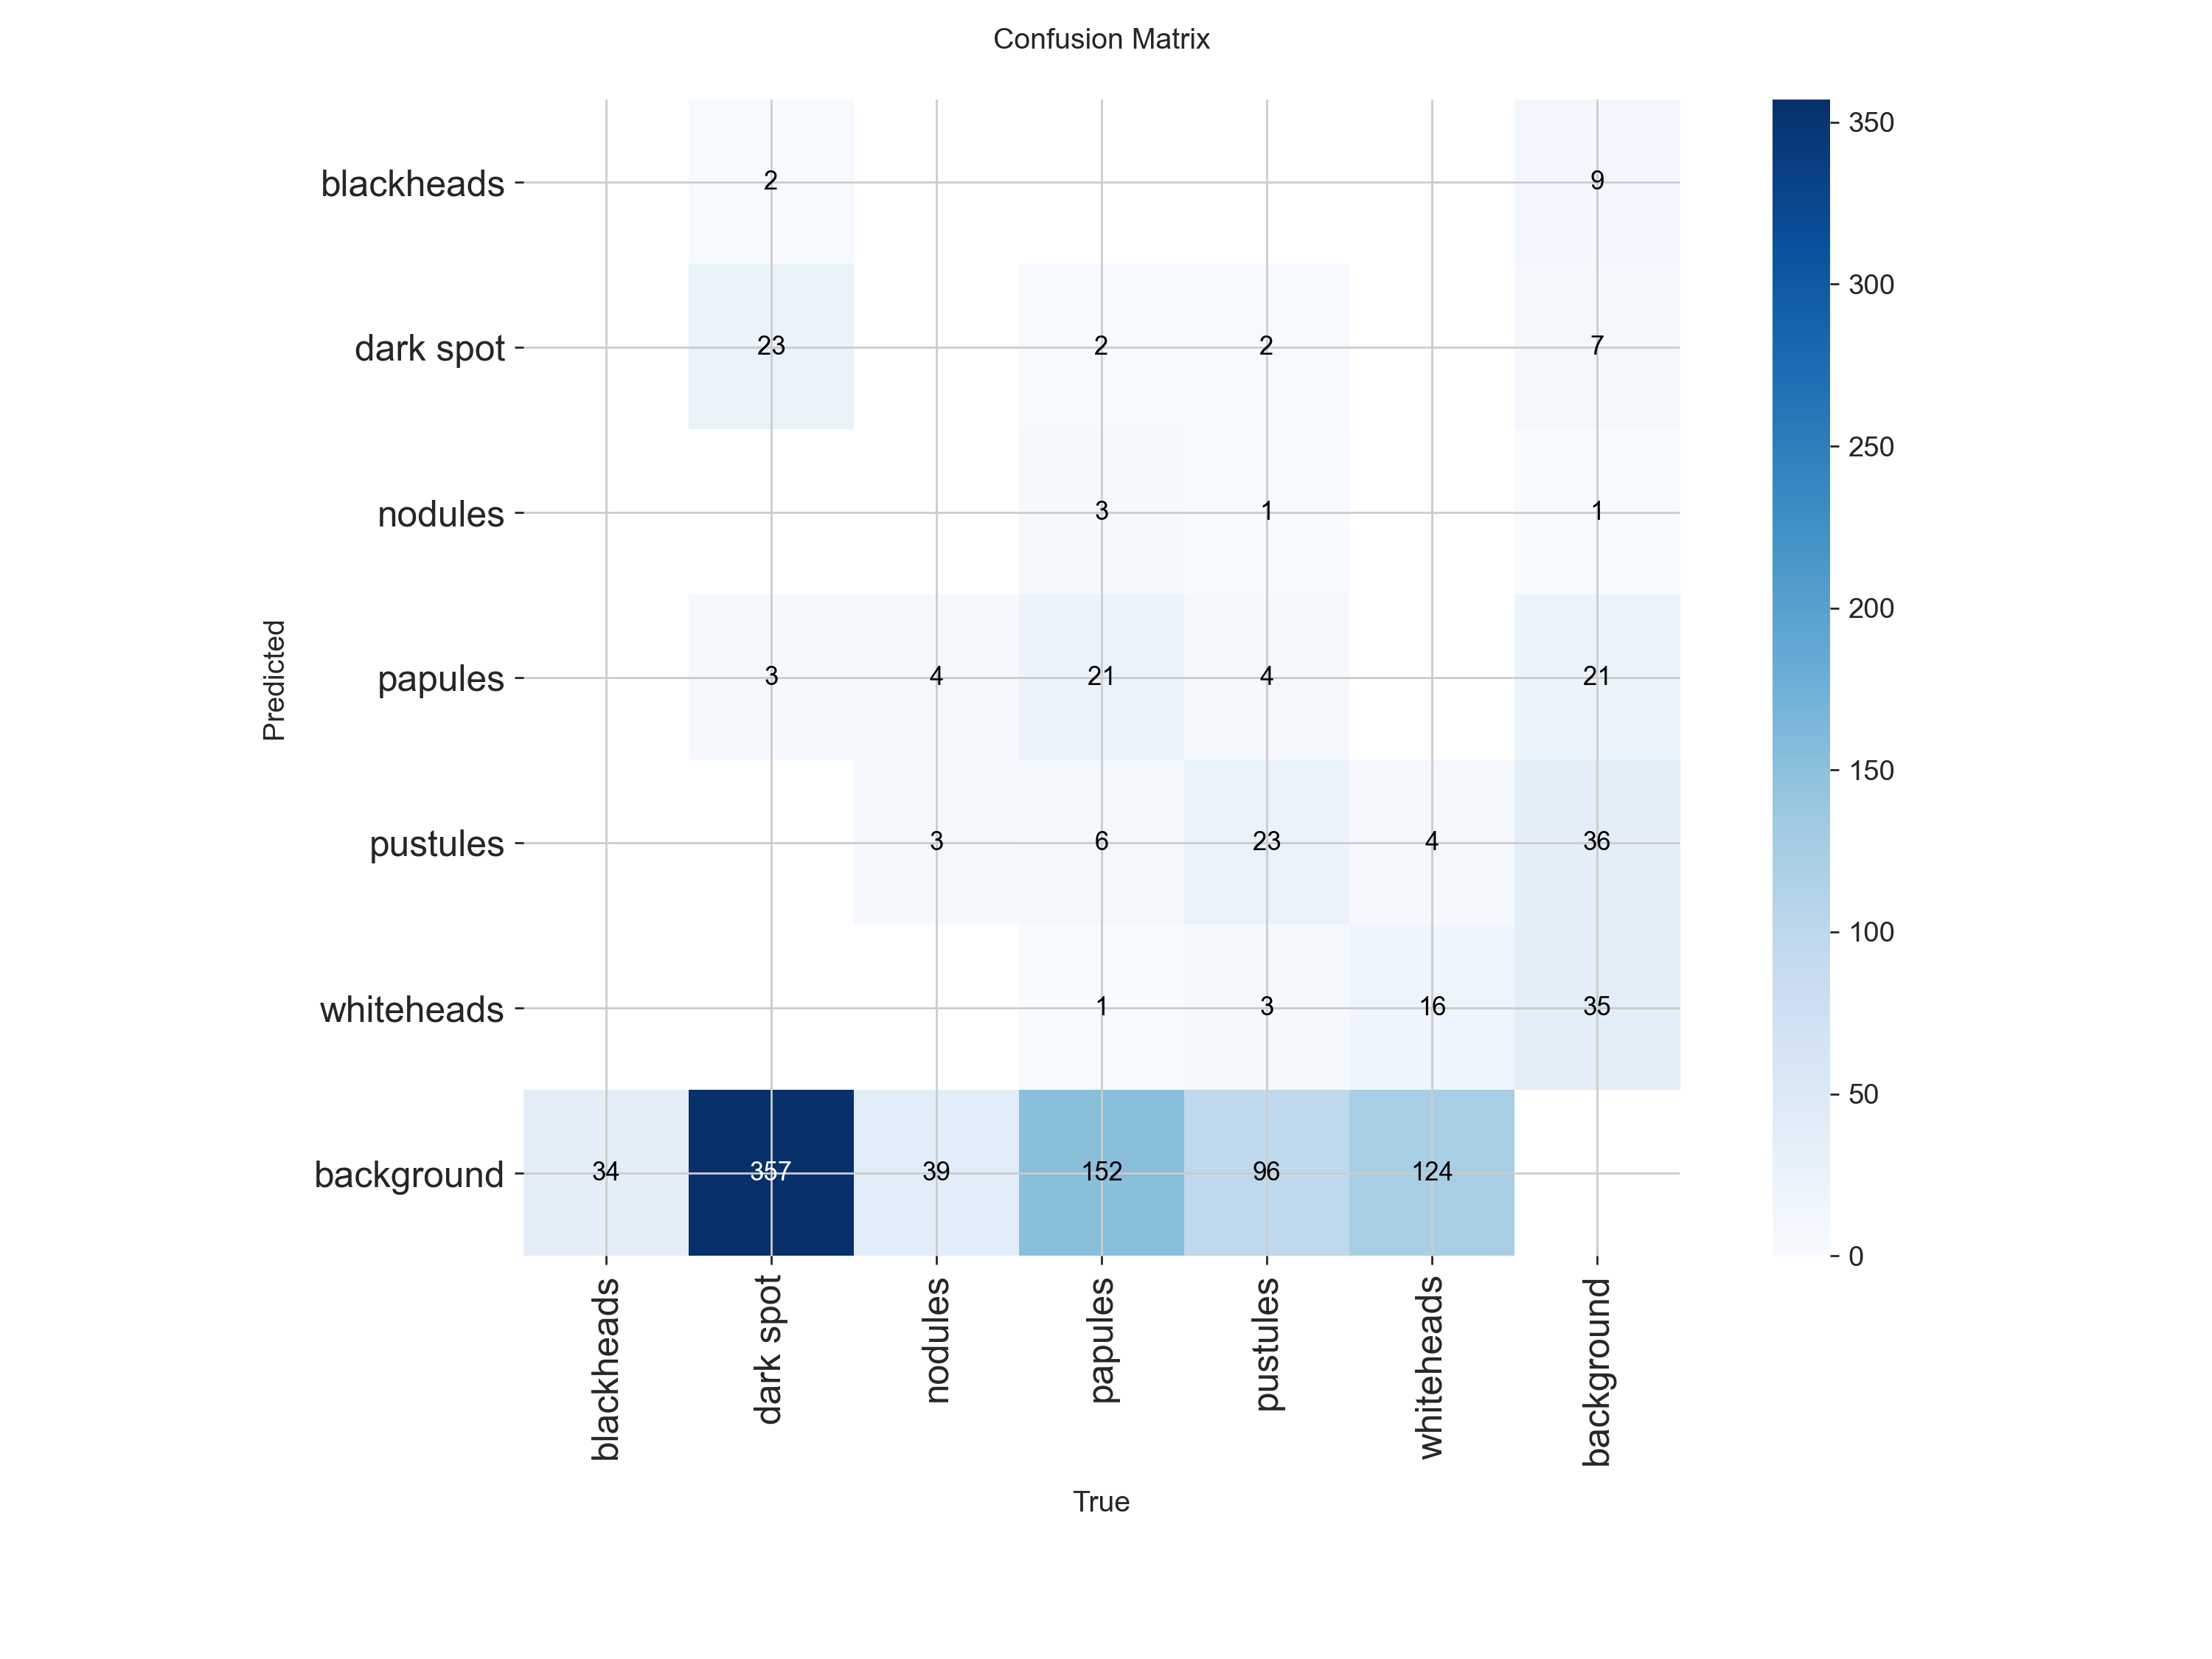

In [5]:
# Kiểm tra xem confusion matrix đã được tạo chưa
confusion_matrix_path = os.path.join(results.save_dir, 'confusion_matrix.png')

if os.path.exists(confusion_matrix_path):
    print(f"Confusion matrix đã được tạo tại: {confusion_matrix_path}")
    from IPython.display import Image, display
    display(Image(confusion_matrix_path))
else:
    print("Không tìm thấy confusion matrix. Tiếp tục tạo confusion matrix thủ công...")

## 4. Tạo Confusion Matrix chi tiết từ predictions và ground truth

In [6]:
def load_ground_truth_labels(label_file):
    """Load ground truth labels từ file .txt (YOLO format)"""
    labels = []
    if not os.path.exists(label_file):
        return labels
    
    with open(label_file, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                class_id = int(parts[0])
                labels.append(class_id)
    return labels

# Thu thập predictions và ground truth từ test set
test_images = list(Path(TEST_IMAGES_DIR).glob("*.jpg")) + list(Path(TEST_IMAGES_DIR).glob("*.png"))
print(f"Số ảnh test: {len(test_images)}")

all_predictions = []
all_ground_truth = []

print("\nĐang thu thập predictions và ground truth...")
for idx, img_path in enumerate(test_images):
    if (idx + 1) % 20 == 0:
        print(f"Đã xử lý: {idx + 1}/{len(test_images)} ảnh")
    
    # Lấy label file tương ứng
    label_file = img_path.parent.parent / "labels" / (img_path.stem + ".txt")
    
    # Load ground truth
    gt_labels = load_ground_truth_labels(label_file)
    
    # Dự đoán
    pred_results = model.predict(
        str(img_path),
        conf=0.25,
        iou=0.45,
        verbose=False
    )
    
    # Lấy predictions
    pred_labels = []
    if pred_results[0].boxes is not None and len(pred_results[0].boxes) > 0:
        pred_classes = pred_results[0].boxes.cls.cpu().numpy().astype(int)
        pred_labels = pred_classes.tolist()
    
    all_ground_truth.extend(gt_labels)
    all_predictions.extend(pred_labels)

print(f"\nTổng số objects trong ground truth: {len(all_ground_truth)}")
print(f"Tổng số objects được phát hiện: {len(all_predictions)}")

Số ảnh test: 92

Đang thu thập predictions và ground truth...
Đã xử lý: 20/92 ảnh
Đã xử lý: 40/92 ảnh
Đã xử lý: 60/92 ảnh
Đã xử lý: 80/92 ảnh

Tổng số objects trong ground truth: 923
Tổng số objects được phát hiện: 241


In [7]:
# Thống kê theo class
print("=== Thống kê Ground Truth theo class ===")
gt_counts = {i: all_ground_truth.count(i) for i in range(num_classes)}
for i, class_name in enumerate(class_names):
    print(f"{class_name}: {gt_counts[i]}")

print("\n=== Thống kê Predictions theo class ===")
pred_counts = {i: all_predictions.count(i) for i in range(num_classes)}
for i, class_name in enumerate(class_names):
    print(f"{class_name}: {pred_counts[i]}")

=== Thống kê Ground Truth theo class ===
blackheads: 34
dark spot: 385
nodules: 46
papules: 185
pustules: 129
whiteheads: 144

=== Thống kê Predictions theo class ===
blackheads: 11
dark spot: 44
nodules: 4
papules: 58
pustules: 75
whiteheads: 49


## 5. Tính toán và vẽ Confusion Matrix

In [8]:
# Tạo confusion matrix
cm = confusion_matrix(
    all_ground_truth, 
    all_predictions, 
    labels=list(range(num_classes))
)

# Normalize confusion matrix (tính theo phần trăm)
cm_normalized = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-8)
cm_percent = cm_normalized * 100

print("Confusion Matrix (số lượng tuyệt đối):")
print(cm)
print("\nConfusion Matrix (phần trăm):")
print(cm_percent)

ValueError: Found input variables with inconsistent numbers of samples: [923, 241]

In [ ]:
# Vẽ confusion matrix với số lượng tuyệt đối và phần trăm
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Plot 1: Confusion matrix với số lượng tuyệt đối
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0],
    cbar_kws={'label': 'Số lượng'}
)
axes[0].set_xlabel('Dự đoán (Predicted)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Thực tế (Actual)', fontsize=12, fontweight='bold')
axes[0].set_title('Confusion Matrix - Số lượng tuyệt đối', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='both', which='major', labelsize=10)

# Plot 2: Confusion matrix với phần trăm (normalized)
sns.heatmap(
    cm_percent,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[1],
    cbar_kws={'label': 'Phần trăm (%)'}
)
axes[1].set_xlabel('Dự đoán (Predicted)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Thực tế (Actual)', fontsize=12, fontweight='bold')
axes[1].set_title('Confusion Matrix - Phần trăm (Normalized)', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='both', which='major', labelsize=10)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix_detailed.png'), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Vẽ confusion matrix lớn với phần trăm
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    cm_percent,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax,
    cbar_kws={'label': 'Phần trăm (%)'},
    annot_kws={'size': 12}
)
ax.set_xlabel('Dự đoán (Predicted)', fontsize=14, fontweight='bold')
ax.set_ylabel('Thực tế (Actual)', fontsize=14, fontweight='bold')
ax.set_title('Confusion Matrix - Phần trăm', fontsize=16, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix_large.png'), dpi=300, bbox_inches='tight')
plt.show()

## 6. Tính toán các metrics đánh giá chi tiết

In [ ]:
# Tính toán classification report
report = classification_report(
    all_ground_truth,
    all_predictions,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

# In ra metrics cho từng class
print("=== Metrics theo từng class ===")
for i, class_name in enumerate(class_names):
    if class_name in report:
        precision = report[class_name]['precision']
        recall = report[class_name]['recall']
        f1 = report[class_name]['f1-score']
        support = report[class_name]['support']
        print(f"\n{class_name}:")
        print(f"  Precision: {precision:.4f} ({precision*100:.2f}%)")
        print(f"  Recall: {recall:.4f} ({recall*100:.2f}%)")
        print(f"  F1-score: {f1:.4f} ({f1*100:.2f}%)")
        print(f"  Support: {int(support)}")

# Overall metrics
print("\n=== Overall Metrics ===")
print(f"Accuracy: {report['accuracy']:.4f} ({report['accuracy']*100:.2f}%)")
print(f"Macro avg Precision: {report['macro avg']['precision']:.4f}")
print(f"Macro avg Recall: {report['macro avg']['recall']:.4f}")
print(f"Macro avg F1-score: {report['macro avg']['f1-score']:.4f}")
print(f"Weighted avg Precision: {report['weighted avg']['precision']:.4f}")
print(f"Weighted avg Recall: {report['weighted avg']['recall']:.4f}")
print(f"Weighted avg F1-score: {report['weighted avg']['f1-score']:.4f}")

## 7. Vẽ biểu đồ so sánh Precision, Recall, F1-score theo từng class

In [ ]:
# Vẽ biểu đồ so sánh metrics
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(class_names))
width = 0.25

precision_values = [report[name]['precision'] if name in report else 0 for name in class_names]
recall_values = [report[name]['recall'] if name in report else 0 for name in class_names]
f1_values = [report[name]['f1-score'] if name in report else 0 for name in class_names]

bars1 = ax.bar(x - width, precision_values, width, label='Precision', color='#3498db')
bars2 = ax.bar(x, recall_values, width, label='Recall', color='#2ecc71')
bars3 = ax.bar(x + width, f1_values, width, label='F1-score', color='#e74c3c')

ax.set_xlabel('Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Precision, Recall, F1-score theo từng class', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.legend()
ax.set_ylim([0, 1.1])
ax.grid(axis='y', alpha=0.3)

# Thêm giá trị trên các cột
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'metrics_by_class.png'), dpi=300, bbox_inches='tight')
plt.show()

## 8. Lưu báo cáo đánh giá

In [ ]:
# Lưu báo cáo đánh giá ra file text
report_path = os.path.join(OUTPUT_DIR, 'evaluation_report.txt')

with open(report_path, 'w', encoding='utf-8') as f:
    f.write("=" * 80 + "\n")
    f.write("BÁO CÁO ĐÁNH GIÁ MÔ HÌNH YOLOV8 MULTICLASS\n")
    f.write("=" * 80 + "\n\n")
    
    f.write("THÔNG TIN MÔ HÌNH:\n")
    f.write(f"- Model path: {MODEL_PATH}\n")
    f.write(f"- Data config: {DATA_YAML}\n")
    f.write(f"- Test images: {TEST_IMAGES_DIR}\n\n")
    
    f.write("THỐNG KÊ DỮ LIỆU:\n")
    f.write(f"- Tổng số objects trong ground truth: {len(all_ground_truth)}\n")
    f.write(f"- Tổng số objects được phát hiện: {len(all_predictions)}\n")
    f.write(f"- Số lớp: {len(class_names)}\n\n")
    
    f.write("DANH SÁCH CÁC LỚP:\n")
    for i, class_name in enumerate(class_names):
        gt_count = all_ground_truth.count(i)
        pred_count = all_predictions.count(i)
        f.write(f"  {i}. {class_name}: GT={gt_count}, Pred={pred_count}\n")
    f.write("\n")
    
    f.write("=" * 80 + "\n")
    f.write("METRICS TỪ YOLOV8 VALIDATION\n")
    f.write("=" * 80 + "\n")
    f.write(f"Precision (B): {results.results_dict.get('metrics/precision(B)', 0):.4f}\n")
    f.write(f"Recall (B): {results.results_dict.get('metrics/recall(B)', 0):.4f}\n")
    f.write(f"mAP50 (B): {results.results_dict.get('metrics/mAP50(B)', 0):.4f}\n")
    f.write(f"mAP50-95 (B): {results.results_dict.get('metrics/mAP50-95(B)', 0):.4f}\n\n")
    
    f.write("=" * 80 + "\n")
    f.write("CONFUSION MATRIX (Số lượng tuyệt đối)\n")
    f.write("=" * 80 + "\n")
    f.write("Actual \\ Predicted\t" + "\t".join(class_names) + "\n")
    for i, class_name in enumerate(class_names):
        row = f"{class_name}\t\t"
        row += "\t".join([str(int(cm[i, j])) for j in range(len(class_names))])
        f.write(row + "\n")
    f.write("\n")
    
    f.write("=" * 80 + "\n")
    f.write("CONFUSION MATRIX (Phần trăm)\n")
    f.write("=" * 80 + "\n")
    f.write("Actual \\ Predicted\t" + "\t".join(class_names) + "\n")
    for i, class_name in enumerate(class_names):
        row = f"{class_name}\t\t"
        row += "\t".join([f"{cm_normalized[i, j]*100:.2f}%" for j in range(len(class_names))])
        f.write(row + "\n")
    f.write("\n")
    
    f.write("=" * 80 + "\n")
    f.write("METRICS ĐÁNH GIÁ CHI TIẾT\n")
    f.write("=" * 80 + "\n\n")
    
    f.write("Metrics theo từng class:\n")
    for i, class_name in enumerate(class_names):
        if class_name in report:
            precision = report[class_name]['precision']
            recall = report[class_name]['recall']
            f1 = report[class_name]['f1-score']
            support = report[class_name]['support']
            f.write(f"\n{class_name}:\n")
            f.write(f"  Precision: {precision:.4f} ({precision*100:.2f}%)\n")
            f.write(f"  Recall: {recall:.4f} ({recall*100:.2f}%)\n")
            f.write(f"  F1-score: {f1:.4f} ({f1*100:.2f}%)\n")
            f.write(f"  Support: {int(support)}\n")
    
    f.write("\n" + "=" * 80 + "\n")
    f.write("Overall Metrics:\n")
    f.write("=" * 80 + "\n")
    f.write(f"Accuracy: {report['accuracy']:.4f} ({report['accuracy']*100:.2f}%)\n")
    f.write(f"Macro avg Precision: {report['macro avg']['precision']:.4f}\n")
    f.write(f"Macro avg Recall: {report['macro avg']['recall']:.4f}\n")
    f.write(f"Macro avg F1-score: {report['macro avg']['f1-score']:.4f}\n")
    f.write(f"Weighted avg Precision: {report['weighted avg']['precision']:.4f}\n")
    f.write(f"Weighted avg Recall: {report['weighted avg']['recall']:.4f}\n")
    f.write(f"Weighted avg F1-score: {report['weighted avg']['f1-score']:.4f}\n")

print(f"Đã lưu báo cáo đánh giá tại: {report_path}")

## Kết luận

Notebook này đã hoàn thành:
- ✅ Đánh giá mô hình YOLOv8 trên test set
- ✅ Tạo confusion matrix (số lượng và phần trăm)
- ✅ Tính toán các metrics: Precision, Recall, F1-score cho từng class
- ✅ Vẽ biểu đồ so sánh metrics theo từng class
- ✅ Lưu báo cáo đánh giá chi tiết

Các file đã được lưu tại thư mục output:
- `confusion_matrix.png` - Confusion matrix từ YOLOv8 validation
- `confusion_matrix_detailed.png` - Confusion matrix chi tiết (2 biểu đồ)
- `confusion_matrix_large.png` - Confusion matrix lớn với phần trăm
- `metrics_by_class.png` - Biểu đồ so sánh Precision, Recall, F1-score
- `evaluation_report.txt` - Báo cáo đánh giá chi tiết